# Atelier Scikit-learn

## Contexte 
Une entreprise possède plusieurs bâtiments équipés de capteurs IoT. 
Chaque capteur collecte régulièrement des informations sur la température, l'humidité, la pression, 
la consommation énergétique, le bâtiment, la date et l'heure de la mesure.  
Chaque mesure possède également un état (OK, ALERTE et ERREUR). 
L'objectif de l'atelier est de construire un modèle capable de prédire automatiquement l'état d'un 
capteur à partir de ses mesures. 
L'atelier suivra le workflow classique du Machine Learning : 
Dataset → Chargement → Exploration → Nettoyage → X / y → Train / Test → Prétraitement → 
Modèle → fit()→ predict()→ Évaluation → Sauvegarde → Chargement → Réutilisation

## Partie 0 – mise en place de l’environnement

### 4) Installer et importer seaborn, matplotlib et pandas

In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:

import seaborn as sns

In [3]:
import matplotlib.pyplot as plt

In [4]:
import pandas as pd

In [5]:
import numpy as np

### 5) Importer mesures_capteurs.csv dans le dataframe df 

In [6]:
df= pd.read_csv("../data/mesures_capteurs (1).csv")

### 6) Explorer le dataframe

In [7]:
# Aperçu
print("Entete du tableau \n", df.head)


Entete du tableau 
 <bound method NDFrame.head of     id_mesure           date_heure id_capteur batiment  temperature  humidite  \
0       M0413  2026-01-22 04:00:00       C005     B002        25.46     58.06   
1       M0290  2026-01-17 01:00:00       C002     B001        24.00     79.73   
2       M0077  2026-01-08 04:00:00       C005     B002        25.82     54.47   
3       M0079  2026-01-08 06:00:00       C007     B003        28.23     69.39   
4       M0183  2026-01-12 14:00:00       C003     B001        20.58     53.80   
..        ...                  ...        ...      ...          ...       ...   
600     M0072  2026-01-07 23:00:00       C012     B004        23.67     60.28   
601     M0107  2026-01-09 10:00:00       C011     B004        24.34     61.42   
602     M0271  2026-01-16 06:00:00       C007     B003        23.73     63.49   
603     M0436  2026-01-23 03:00:00       C004     B002        24.83     79.77   
604     M0103  2026-01-09 06:00:00       C007     B003     

In [8]:
# Dimensions du dataframe
print("Dimensions du dataframe: \n", df.shape)

Dimensions du dataframe: 
 (605, 9)


In [9]:
# Nombre d'élements du dataframe
print ("Nombre d'élements du dataframe: \n", df.size)

Nombre d'élements du dataframe: 
 5445


In [10]:
# Desrcription du dataframe
print("Description du dataframe \n", df.info())

<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     605 non-null    str    
 1   date_heure    605 non-null    str    
 2   id_capteur    605 non-null    str    
 3   batiment      605 non-null    str    
 4   temperature   599 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          601 non-null    str    
dtypes: float64(4), str(5)
memory usage: 42.7 KB
Description du dataframe 
 None


In [11]:
# Statistiques génèrales
print("Statistiques du dataframe \n", df.describe())

Statistiques du dataframe 
        temperature   humidite     pression  consommation
count   599.000000  600.00000   600.000000    600.000000
mean     24.878314   64.92620  1012.221900    208.675417
std       4.059576   10.76905    10.599042     72.243567
min     -18.500000   28.52000   850.000000     18.120000
25%      22.570000   58.17250  1006.790000    160.177500
50%      24.860000   65.37500  1012.855000    206.150000
75%      27.275000   71.61500  1017.827500    254.127500
max      58.700000  145.00000  1038.430000    875.000000


## Partie 1 – Gestion des doublons

**Avec Pandas**
### 1) vérifier l’existence de doublons dans df

In [12]:
nb_doublons= df.duplicated().sum()
print(nb_doublons)

5


Il existe 5 doublons au niveaui du dataframe

### 2) Le cas échéant, supprimer les doublons puis vérifier la suppression

Comme que nous avons constaté 5 doublons dans notre dafatframe, nous procédons à leur suppression

In [13]:
df= df.drop_duplicates()

**Vérification de la suppression des doublons**

In [14]:
nb_doublons_actuels= df.duplicated().sum()
print("Le nombre de doublons actuels est de: ", nb_doublons_actuels)

Le nombre de doublons actuels est de:  0


## Partie 2 – Sélection de y (cible) et X (caractéristiques) 

### 1) Définir "etat" comme la cible ou valeur à prédire et "temperature", "humidite", "pression" et "consommation" comme caractéristiques ou variables explicatives 

In [15]:
# Caractéristiques ou variables explicatives X
features = ["temperature", "humidite", "pression", "consommation"]
X = df[features]
y = df["etat"]

### 2) Afficher les cinq premières lignes de X et de y 

In [16]:
# 5 premières lignes de X
# X est une matrice 2D
print("Les 5 premières lignes de X sont: \n", X.head)

Les 5 premières lignes de X sont: 
 <bound method NDFrame.head of      temperature  humidite  pression  consommation
0          25.46     58.06   1008.95        287.28
1          24.00     79.73    993.39        116.20
2          25.82     54.47   1010.32        288.50
3          28.23     69.39   1019.62        136.65
4          20.58     53.80   1016.58        182.62
..           ...       ...       ...           ...
600        23.67     60.28   1015.11        282.36
601        24.34     61.42   1019.43        357.43
602        23.73     63.49   1016.46        152.79
603        24.83     79.77   1017.05        170.97
604        17.02     52.04   1001.14         44.99

[600 rows x 4 columns]>


In [17]:
# Les 5 premières lignes de 7
#y est une série 1D
print("y")
print("Les 5 premières lignes de y sont : \n", y.head)

y
Les 5 premières lignes de y sont : 
 <bound method NDFrame.head of 0      OK
1      OK
2      OK
3      OK
4      OK
       ..
600    OK
601    OK
602    OK
603    OK
604    OK
Name: etat, Length: 600, dtype: str>


### 3) Quel est le type du problème de machine learning ? 

Pour ce dataframe, nous avons affaire à un problème de classification déjà parceque la cible "etat" contient des catégories discrètes non des valeurs numériques d'où l'exclusion de la piste de la régression où on essaye de prédire des valeurs numériques. De plus le problème de machine learning ici est un cas de classification multiclasses et non binaires vu que la cible "etat" contient plus de deux classes possibles (OK ERRUER ALERTE).
Le modèle que nous devrons entrainé devra donc apprendre à partir des valeurs explicatives à assigner un etat parmi ceux compris dans la cible.

## Partie 3 – Découpage Train/Test 

### Diviser X en deux ensembles distincts : un pour l'entraînement (train) et un pour le test (test). Avec les conditions suivantes : **20% des données serviront au test** ; garantir la **reproductibilité du découpage** ; conserver les **mêmes proportions de classes** dans l'ensemble de train et de test que dans les données d'origine. 

In [18]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.3 MB 3.6 MB/s eta 0:00:03
   ------- -------------------------------- 1.6/8.3 MB 3.6 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.3 MB 3.7 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.3 MB 3.5 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.3 MB 3.5 MB/s eta 0:00:02
   ------------------------- -------------- 5.2/8.3 MB 3.5 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.3 MB 3.7 MB/s eta 0:00:01
   -------------------------------- ------- 6.8/8.3 MB 3.7 MB/s eta 0:00:01
   ----------------------------------- ---- 7.3/8.3 MB 3.4 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.3 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 3.1 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 3.1 MB/s eta 0:00:01
   ----------------

Dans un premier temp nous avons tenté de faire les découpages mais une erreur nous a été signalé disant qu'il existe des vaeurs manquantes au niveau des inputss? Ainsi nous allons faire cette vérification et régler le probléme des valeurs manquantes avant de revenir faire le découpage.

In [25]:
# Supprimer les lignes où la cible (etat) est manquante
mask = y.notna()
X = X[mask]
y = y[mask]

print(f"Lignes restantes après suppression des y manquants : {len(y)}")
print(y.isna().sum())  # doit afficher 0

Lignes restantes après suppression des y manquants : 596
0


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train :", X_train.shape, " X_test :", X_test.shape)
print("\nRépartition des classes (train) :")
print(y_train.value_counts(normalize=True).round(3))
print("\nRépartition des classes (test) :")
print(y_test.value_counts(normalize=True).round(3))

X_train : (476, 4)  X_test : (120, 4)

Répartition des classes (train) :
etat
OK        0.943
ALERTE    0.048
ERREUR    0.008
Name: proportion, dtype: float64

Répartition des classes (test) :
etat
OK        0.942
ALERTE    0.050
ERREUR    0.008
Name: proportion, dtype: float64


## Partie 4 – Gestion des valeurs manquantes

### 1) Vérifier l’existence de valeurs manquantes 

In [27]:
print(X_train.isna().sum())

temperature     5
humidite        4
pression        5
consommation    3
dtype: int64


Le calcul effectué précédemment nous a montré l'existence de valeurs manquantes au niveau des températures, de l'humidité, de la pression, de la consommation et de l'etat.

In [28]:
print (X_test.isna().sum())

temperature     1
humidite        1
pression        0
consommation    2
dtype: int64


### 2) Sélectionner SimpleImputer avec la médiane

In [29]:
from sklearn.impute import SimpleImputer
imputer= SimpleImputer(strategy= "median")

### 3) Qu’est ce qui justifie le choix de la médiane ?

La médiane est robuste aux valeurs extrêmes (outliers), contrairement à la moyenne. Si on utilisait la moyenne pour imputer, ces outliers tireraient la valeur de remplacement vers le haut ou le bas de façon disproportionnée.
**Exemple concret :** Sur les valeurs [20, 21, 22, 23, 95] (95 étant un outlier, capteur défaillant), la moyenne donnerait environ 36.2 — une valeur totalement irréaliste pour remplacer une température manquante — alors que la médiane donnerait 22, bien plus représentative de la tendance réelle des mesures.
Pour des variables physiques comme la température, l'humidité, la pression et la consommation, qui peuvent présenter des pics ponctuels (anomalies de capteurs, comme on l'a vu dans l'atelier Seaborn), la médiane donne une estimation plus fiable et prudente de la valeur manquante que la moyenne.

### 4) Trouver les paramètres (médianes) de l’imputeur sur X_train 

In [30]:
# fit() permet de calculer la mediane sur toutes les colonnes qui sont dans X_train
imputer.fit(X_train)
print("Les médianes pour temperature, humidité, pression et consommation sont respectivement de : \n", imputer.statistics_)

Les médianes pour temperature, humidité, pression et consommation sont respectivement de : 
 [  24.9    65.38 1012.3   206.59]


### 5) Déterminer X_train_imputed et X_test_imputed, les transformés de X_train et X_test

In [31]:
X_train_imputed = pd.DataFrame(imputer.transform(X_train), columns=features, index=X_train.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=features, index=X_test.index)

print("Valeurs manquantes restantes (train) :", X_train_imputed.isna().sum().sum())
print("Valeurs manquantes restantes (test) :", X_test_imputed.isna().sum().sum())

Valeurs manquantes restantes (train) : 0
Valeurs manquantes restantes (test) : 0


## Partie 5 – Mise à l'échelle 

### 1) Sélectionner StandardScaler pour mettre à l’échelle les transformés de l’imputation 

In [32]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()

### 2) Qu’est ce qui justifie la standardisation ? 

KNN se base sur une distance (généralement euclidienne) entre les points pour trouver les "voisins" les plus proches. Si pression varie entre 990 et 1020 (échelle ~30) et temperature entre 15 et 35 (échelle ~20), mais que consommation varie entre 50 et 300 (échelle ~250), alors la distance calculée par l'algorithme sera dominée par la variable à la plus grande échelle (la consommation), même si elle n'est pas forcément la plus pertinente pour prédire l'état du capteur. Sans standardisation, KNN "écouterait" surtout la consommation et presque pas la pression.
La standardisation transforme chaque variable pour qu'elle ait une moyenne de 0 et un écart-type de 1, remettant ainsi toutes les variables sur un pied d'égalité, indépendamment de leur échelle d'origine.
Formule utilisée par StandardScaler pour chaque valeur : (x - moyenne) / écart_type.

### 3) Trouver les paramètres (moyennes et écart-types) du scaleur sur X_train_imputed

In [33]:
scaler. fit(X_train_imputed)
print("Moyenne : ", scaler.mean_)
print("Ecart-type: ", scaler.scale_)

Moyenne :  [  24.9637395    64.85044118 1012.07621849  210.15394958]
Ecart-type:  [ 4.19303979 10.16279173 10.9941836  73.42092322]


### 4) Déterminer X_train_scaled et X_test_scaled, les transformés de X_train_imputed et X_test_imputed 

In [34]:
X_train_scaled = pd.DataFrame(scaler.transform(X_train_imputed), columns=features, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imputed), columns=features, index=X_test.index)

X_train_scaled.describe().round(2)

,temperature,humidite,pression,consommation
count,476.00,476.00,476.00,476.00
mean,-0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00
min,-10.37,-2.86,-14.74,-2.62
25%,-0.55,-0.66,-0.49,-0.68
50%,-0.02,0.05,0.02,-0.05
75%,0.56,0.66,0.52,0.61
max,8.05,2.78,2.40,9.06


## Partie 6 – Entrainement et prédiction d’un modèle

### 1) Sélectionner le modèle KNN (k plus proches voisins) avec 5, le nombre de voisins à prendre en compte 
### 2) Entrainer le modèle

In [35]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](3,)","['ALERTE','ERREUR','OK']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


### 3) Déterminer y_pred, la prédiction du modèle avec l’ensemble de test 

In [36]:
y_pred = model.predict(X_test_scaled)
y_pred[:10]

array(['OK', 'OK', 'OK', 'OK', 'OK', 'OK', 'OK', 'OK', 'OK', 'OK'],
      dtype=object)

### 4) Afficher quelques prédictions 

In [37]:
resultats = pd.DataFrame({
    "y_test (reel)": y_test.values[:10],
    "y_pred (predit)": y_pred[:10]
})
resultats

,y_test (reel),y_pred (predit)
0,OK,OK
1,OK,OK
2,OK,OK
3,OK,OK
4,ALERTE,OK
5,OK,OK
6,OK,OK
7,OK,OK
8,OK,OK
9,OK,OK


### 5) Comparer ces prédictions avec les vraies valeurs 

In [38]:
comparaison = pd.DataFrame({"reel": y_test.values, "predit": y_pred})
comparaison["correct"] = comparaison["reel"] == comparaison["predit"]
print(comparaison["correct"].value_counts())
comparaison.head(15)

correct
True     115
False      5
Name: count, dtype: int64


,reel,predit,correct
0,OK,OK,True
1,OK,OK,True
2,OK,OK,True
3,OK,OK,True
4,ALERTE,OK,False
5,OK,OK,True
6,OK,OK,True
7,OK,OK,True
8,OK,OK,True
9,OK,OK,True


## Partie 7 – Evaluation du modèle

### 1) Evaluer le modèle avec Accuracy puis afficher le résultat

In [39]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy : {accuracy:.3f}")

Accuracy : 0.958


### 2) Pourquoi Accuracy ne suffit pas toujours pour évaluer ?

Le dataset est déséquilibré : on avait vu dans l'atelier Seaborn (Partie 5) que la classe OK représente la grande majorité des mesures (130+ par bâtiment), tandis qu'ALERTE et ERREUR sont rares (quelques unités seulement).
Dans ce contexte, un modèle qui prédirait toujours "OK", sans même regarder les données, obtiendrait déjà une accuracy très élevée (par exemple 90%+) simplement parce que OK est ultra-majoritaire sans jamais détecter une seule alerte ou erreur. Ce serait un modèle inutile en pratique (l'objectif métier est justement de détecter les anomalies !), mais l'accuracy seule le ferait paraître excellent.
C'est le piège classique de l'accuracy sur des classes déséquilibrées : elle peut cacher un échec total sur les classes minoritaires, qui sont pourtant souvent les plus importantes à détecter (ici, ALERTE et ERREUR).
D'où la nécessité d'utiliser des métriques qui regardent la performance classe par classe (matrice de confusion, precision, recall, F1) plutôt qu'un seul chiffre global.

### 3) Déterminer, afficher et commenter la matrice de confusion

In [40]:
from sklearn.metrics import confusion_matrix

matrice = confusion_matrix(y_test, y_pred, labels=model.classes_)
# labels=model.classes_ garantit que l'ordre des lignes/colonnes correspond bien à l'ordre des classes appris par le modèle (évite toute ambiguïté).
print(matrice)
print("Ordre des classes :", model.classes_)

[[  2   0   4]
 [  1   0   0]
 [  0   0 113]]
Ordre des classes : ['ALERTE' 'ERREUR' 'OK']


La matrice de confusion montre, pour chaque vraie classe (en ligne), comment le modèle a réparti ses prédictions (en colonnes). On peut ainsi voir si le modèle confond ALERTE avec OK, ou ERREUR avec ALERTE par exemple — des informations invisibles derrière une simple accuracy globale.

### 4) Visualiser cette matrice avec Seaborn

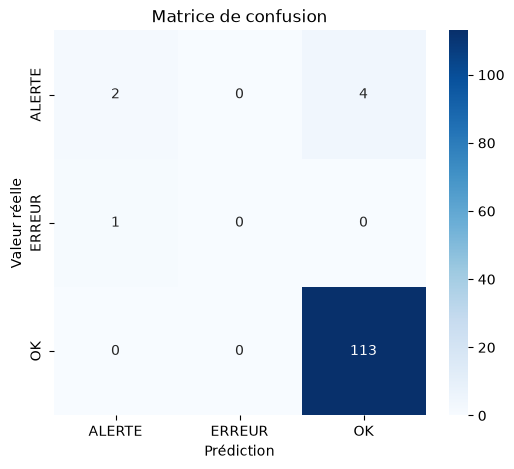

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(matrice, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")
plt.title("Matrice de confusion")
plt.show()


### 5) Afficher et commenter le rapport de classificaton

In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      ALERTE       0.67      0.33      0.44         6
      ERREUR       0.00      0.00      0.00         1
          OK       0.97      1.00      0.98       113

    accuracy                           0.96       120
   macro avg       0.54      0.44      0.48       120
weighted avg       0.94      0.96      0.95       120



c:\Users\pc\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pc\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pc\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

### 6) Dans quel cas de problème de classification est-il plus indiqué d’évaluer avec la precision ; même question avec recall; même question avec F1 score; même question avec accuracy

| Métrique | Ce qu'elle mesure | Cas d'usage typique |
|---|---|---|
| **Precision** | Parmi les mesures prédites "ALERTE", combien le sont vraiment ? | Quand une fausse alerte coûte cher (ex. déplacement inutile d'une équipe de maintenance, perte de confiance dans le système) |
| **Recall** | Parmi les vraies "ALERTE", combien le modèle en a détecté ? | Quand rater une vraie anomalie est dangereux/coûteux — cas typique en IoT : ne pas détecter une ERREUR peut mener à une panne non anticipée |
| **F1-score** | Compromis entre precision et recall | Quand on veut un équilibre entre les deux, notamment utile sur des classes déséquilibrées |
| **Accuracy** | % de bonnes prédictions global | Utile seulement quand les classes sont

## Partie 8 – Sauvegarde du modèle

### 1) Sauvegarder le modèle avec Joblib pour avoir models/modele_capteurs.joblib

In [46]:
import joblib

joblib.dump(model, "../models/modele_capteurs.joblib")
print("Modèle sauvegardé avec Joblib")


Modèle sauvegardé avec Joblib


### 2) Sauvegarder le modèle avec Pickle pour avoir models/modele_capteurs.pkl

In [44]:
import pickle

with open("../models/modele_capteurs.pkl", "wb") as f:
    pickle.dump(model, f)
print("Modèle sauvegardé avec Pickle")

Modèle sauvegardé avec Pickle
